# Timing-Based Overlap Features for HMM Analysis

Reconstruct overlap features using **pure timing-based subtypes** from transcript TSVs, then engineer collaboration-aware metrics.

**Overlap timing subtypes (from relabel_overlaps.py):**
- `simultaneous`: start_diff < 200ms
- `backchannel_ovl`: overlap < 250ms
- `smooth`: overlap 250–500ms
- `competitive`: overlap 500–1000ms (TIMING, not semantic)
- `floor_fight`: overlap ≥ 1000ms

**Context labels (lexical cues, separate layer):**
- `collaborative`: support words on long overlap (contradicts timing)
- `competitive`: conflict words on short overlap (contradicts timing)
- empty: timing and lexical signals agree

In [20]:
import pandas as pd
import numpy as np
from pathlib import Path
import logging
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('timing_features')

# Set paths
REPO_ROOT = Path('../../').resolve()
TRANSCRIPT_DIR = REPO_ROOT / 'transcripts' / 'final'  # Most recent, includes _reviewed files with context_label
FEATURE_EXPORT_DIR = REPO_ROOT / '_tmp_collective_fullsample_export' / 'features'
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Transcript dir: {TRANSCRIPT_DIR}")
print(f"Feature export dir: {FEATURE_EXPORT_DIR}")

Repo root: C:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing
Transcript dir: C:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\transcripts\final
Feature export dir: C:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing\_tmp_collective_fullsample_export\features


## 1. Load transcript TSVs and inspect overlap structure

In [21]:
import re

# Filename regex handles both formats:
#   transcript_grp-07_T1_2026-06-17 (2).tsv    → grp-07 / T1
#   transcript_grp11_T1_2026-07-06_reviewed.tsv → grp11  / T1
_FNAME_RE = re.compile(r'transcript_(grp-?\d+)_(T\d+)_', re.IGNORECASE)

# Find all transcript TSVs (both grp-XX and grpXX naming styles)
transcript_files = [
    f for f in sorted(TRANSCRIPT_DIR.glob('transcript_grp*.tsv'))
    if not f.name.endswith('.bak.tsv') and _FNAME_RE.search(f.name)
]

print(f"✓ Found {len(transcript_files)} transcript files")
print(f"\nBreakdown:")
reviewed = [f for f in transcript_files if '_reviewed' in f.name]
original = [f for f in transcript_files if '_reviewed' not in f.name]
print(f"  _reviewed (with context_label): {len(reviewed)}")
print(f"  original (timing only):         {len(original)}")
print(f"\nAll files:")
for f in transcript_files:
    m = _FNAME_RE.search(f.name)
    grp, task = m.group(1), m.group(2)
    has_ctx = '✓ context_label' if '_reviewed' in f.name else '  timing only'
    print(f"  [{has_ctx}]  {grp} / {task}  ← {f.name}")

✓ Found 37 transcript files

Breakdown:
  _reviewed (with context_label): 17
  original (timing only):         20

All files:
  [  timing only]  grp-07 / T1  ← transcript_grp-07_T1_2026-06-17 (2).tsv
  [  timing only]  grp-07 / T2  ← transcript_grp-07_T2_2026-06-17.tsv
  [  timing only]  grp-07 / T3  ← transcript_grp-07_T3_2026-06-17.tsv
  [  timing only]  grp-07 / T4  ← transcript_grp-07_T4_2026-06-17.tsv
  [  timing only]  grp-10 / T1  ← transcript_grp-10_T1_2026-06-18.tsv
  [  timing only]  grp-10 / T2  ← transcript_grp-10_T2_2026-06-19.tsv
  [  timing only]  grp-10 / T3  ← transcript_grp-10_T3_2026-06-21.tsv
  [  timing only]  grp-10 / T4  ← transcript_grp-10_T4_2026-06-19.tsv
  [  timing only]  grp-14 / T1  ← transcript_grp-14_T1_2026-06-21.tsv
  [  timing only]  grp-14 / T2  ← transcript_grp-14_T2_2026-06-22 (1).tsv
  [  timing only]  grp-14 / T3  ← transcript_grp-14_T3_2026-06-25.tsv
  [  timing only]  grp-14 / T4  ← transcript_grp-14_T4_2026-06-25.tsv
  [  timing only]  grp-15 

In [6]:
# Load one sample transcript to inspect structure
sample_file = transcript_files[0]
sample_df = pd.read_csv(sample_file, sep='\t')

print(f"Loaded: {sample_file.name}")
print(f"Shape: {sample_df.shape}")
print(f"\nColumns: {list(sample_df.columns)}")
print(f"\nData types:")
print(sample_df.dtypes)

# Check OVL rows
ovl_rows = sample_df[sample_df['type'] == 'OVL']
print(f"\n✓ Found {len(ovl_rows)} OVL (overlap) rows")
print(f"\nOVL columns present:")
ovl_cols = [col for col in sample_df.columns if 'subtype' in col or 'context' in col or 'timing' in col]
print(f"  {ovl_cols}")

print(f"\nSample OVL rows (available columns):")
if len(ovl_rows) > 0:
    cols_to_show = ['type', 'onset', 'duration', 'overlap_ms', 'subtype']
    if 'context_label' in sample_df.columns:
        cols_to_show.append('context_label')
    print(ovl_rows[cols_to_show].head(10))

Loaded: transcript_grp-07_T1_2026-06-17 (2).tsv
Shape: (97, 15)

Columns: ['onset', 'duration', 'speaker', 'text', 'type', 'subtype', 'energy', 'energy_ratio', 'mic', 'confidence', 'gap_prev_ms', 'trp_silence_ms', 'interruption_gap_ms', 'bclatency_ms', 'overlap_ms']

Data types:
onset                  float64
duration               float64
speaker                    str
text                       str
type                       str
subtype                    str
energy                 float64
energy_ratio           float64
mic                        str
confidence                 str
gap_prev_ms            float64
trp_silence_ms         float64
interruption_gap_ms    float64
bclatency_ms           float64
overlap_ms             float64
dtype: object

✓ Found 20 OVL (overlap) rows

OVL columns present:
  ['subtype']

Sample OVL rows (available columns):
   type    onset  duration  overlap_ms        subtype
4   OVL  178.191     5.499     13068.0    floor_fight
6   OVL  183.000     1.000  

## 2. Count overlaps by pure timing subtypes

In [55]:
import re as _re

_FNAME_RE = _re.compile(r'transcript_(grp[_-]?\d+)_(T\d+)_', _re.IGNORECASE)

def _normalize_group_id(raw: str) -> str:
    """Normalize group ID to match base feature matrix format.

    Handles both filename conventions:
      transcript_grp-07_T1_...   → raw='grp-07'  → 'grp-07'  (already correct)
      transcript_grp8_T1_...     → raw='grp8'    → 'grp-08'  (add hyphen, zero-pad)
      transcript_grp11_T1_...    → raw='grp11'   → 'grp-11'  (add hyphen)
    """
    # Remove any existing hyphen/underscore between 'grp' and number
    digits = _re.sub(r'^grp[_-]?', '', raw.lower())
    return f"grp-{int(digits):02d}"


def _dedup_ovl(ovl: pd.DataFrame) -> pd.DataFrame:
    """Deduplicate OVL rows sharing the same onset (10-ms bucket), keep longest."""
    if ovl.empty:
        return ovl
    ovl = ovl.copy()
    ovl['_onset_key'] = ovl['onset'].round(2)
    idx = ovl.groupby('_onset_key')['duration'].idxmax()
    return ovl.loc[idx].drop(columns='_onset_key')


def count_timing_based_overlaps(transcript_files: list, window_s: float = 60) -> pd.DataFrame:
    """Count overlaps by pure timing subtype + context label for each group x task x window.

    Deduplication: multiple OVL rows at the same onset (multi-speaker overlaps) are
    collapsed to one event before counting. Counts and time metrics therefore reflect
    OVERLAP EVENTS, not per-speaker rows.

    Context label is used only for the collaborative/completion index features; all
    timing subtype counts ignore context_label entirely.

    Group IDs are normalized to match the base feature matrix format (grp-08 etc.).
    """
    rows = []

    for fpath in transcript_files:
        try:
            df = pd.read_csv(fpath, sep='\t', dtype=str)
        except Exception as e:
            logger.warning(f"Failed to load {fpath.name}: {e}")
            continue

        m = _FNAME_RE.search(fpath.name)
        if m is None:
            continue
        grp  = _normalize_group_id(m.group(1))   # ← FIXED: normalize to grp-08 format
        task = m.group(2)

        for col in ('onset', 'duration', 'overlap_ms'):
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        df['subtype']       = df.get('subtype',       pd.Series('', index=df.index)).fillna('')
        df['context_label'] = df.get('context_label', pd.Series('', index=df.index)).fillna('')

        task_start = df['onset'].min()
        df['rel_onset'] = df['onset'] - task_start
        df['window_index'] = (df['rel_onset'] / window_s).apply(
            lambda x: int(x) if pd.notna(x) and x >= 0 else -1
        )
        df = df[df['window_index'] >= 0]

        for w_idx, w_df in df.groupby('window_index'):
            ovl_raw = w_df[w_df['type'] == 'OVL'].copy()
            ovl = _dedup_ovl(ovl_raw)

            subtype = ovl['subtype'].str.strip().str.lower()
            n_simult    = (subtype == 'simultaneous').sum()
            n_bcovl     = (subtype == 'backchannel_ovl').sum()
            n_smooth    = (subtype == 'smooth').sum()
            n_compet    = (subtype == 'competitive').sum()
            n_floor     = (subtype == 'floor_fight').sum()

            ovl_count = len(ovl)
            ovl_time_s = ovl['duration'].fillna(0).sum()

            ctx = ovl['context_label'].str.strip().str.lower()
            n_collab      = (ctx == 'collaborative').sum()
            n_completion  = (ctx == 'completion').sum()
            n_ctx_conflict = (ctx == 'competitive').sum()

            collab_idx     = n_collab      / max(ovl_count, 1)
            completion_idx = n_completion  / max(ovl_count, 1)
            conflict_idx   = n_ctx_conflict / max(ovl_count, 1)

            rows.append({
                'group_id': grp, 'task_id': task,
                'window_index': w_idx, 'window_start_s': w_idx * window_s,
                'tr_ovl_count':        ovl_count,
                'tr_ovl_time_s':       round(ovl_time_s, 3),
                'tr_ovl_simultaneous':       n_simult,
                'tr_ovl_backchannel':        n_bcovl,
                'tr_ovl_smooth':             n_smooth,
                'tr_ovl_competitive_timing': n_compet,
                'tr_ovl_floor_fight':        n_floor,
                'tr_ovl_ctx_collaborative':  n_collab,
                'tr_ovl_ctx_completion':     n_completion,
                'tr_ovl_ctx_competitive':    n_ctx_conflict,
                'tr_ovl_collaboration_index': collab_idx,
                'tr_ovl_completion_index':   completion_idx,
                'tr_ovl_conflict_index':     conflict_idx,
            })

    return pd.DataFrame(rows)


timing_features = count_timing_based_overlaps(transcript_files)
print(f"✓ Computed timing-based overlap features for {len(timing_features)} windows")
print(f"Groups/tasks: {timing_features.groupby(['group_id','task_id']).ngroups}")
print()
print("Group IDs in timing_features:", sorted(timing_features['group_id'].unique()))
print()
                        'tr_ovl_ctx_collaborative','tr_ovl_ctx_completion',
                        'tr_ovl_ctx_competitive']].sum().to_string())
print()
print(f"Check: sum of timing subtypes == tr_ovl_count? "

      f"{(timing_features[['tr_ovl_simultaneous','tr_ovl_backchannel','tr_ovl_smooth','tr_ovl_competitive_timing','tr_ovl_floor_fight']].sum(axis=1) == timing_features['tr_ovl_count']).all()}")
                        'tr_ovl_ctx_collaborative','tr_ovl_ctx_completion']].sum().to_string())      f"{(timing_features[['tr_ovl_simultaneous','tr_ovl_backchannel','tr_ovl_smooth','tr_ovl_competitive_timing','tr_ovl_floor_fight']].sum(axis=1) == timing_features['tr_ovl_count']).all()}")

print()print(f"Check: sum of timing subtypes == tr_ovl_count? "

IndentationError: unexpected indent (1297161247.py, line 119)

In [52]:
# Add missing conflict context column directly from transcripts
# (tr_ovl_ctx_competitive = count of overlaps with context_label='competitive')
import re as _re2
_FNAME_RE2 = _re2.compile(r'transcript_(grp[_-]?\d+)_(T\d+)_', _re2.IGNORECASE)

def _norm(raw):
    digits = _re2.sub(r'^grp[_-]?', '', raw.lower())
    return f"grp-{int(digits):02d}"

def _get_conflict_counts(transcript_files, window_s=60):
    rows = []
    for fpath in transcript_files:
        try:
            df = pd.read_csv(fpath, sep='\t', dtype=str)
        except Exception:
            continue
        m = _FNAME_RE2.search(fpath.name)
        if not m:
            continue
        grp, task = _norm(m.group(1)), m.group(2)
        df['onset'] = pd.to_numeric(df.get('onset', pd.Series(dtype=float)), errors='coerce')
        df['duration'] = pd.to_numeric(df.get('duration', pd.Series(dtype=float)), errors='coerce').fillna(0)
        df['context_label'] = df.get('context_label', pd.Series('', index=df.index)).fillna('')
        task_start = df['onset'].min()
        df['window_index'] = ((df['onset'] - task_start) / window_s).apply(
            lambda x: int(x) if pd.notna(x) and x >= 0 else -1)
        df = df[df['window_index'] >= 0]
        for w_idx, w_df in df.groupby('window_index'):
            ovl = w_df[w_df['type'] == 'OVL']
            ctx = ovl['context_label'].str.strip().str.lower()
            n_conflict = (ctx == 'competitive').sum()
            rows.append({'group_id': grp, 'task_id': task, 'window_index': w_idx,
                         'tr_ovl_ctx_competitive': n_conflict})
    return pd.DataFrame(rows)

conflict_counts = _get_conflict_counts(transcript_files)

# Merge into timing_features
timing_features = timing_features.merge(
    conflict_counts, on=['group_id', 'task_id', 'window_index'], how='left'
)
timing_features['tr_ovl_ctx_competitive'] = timing_features['tr_ovl_ctx_competitive'].fillna(0)
timing_features['tr_ovl_conflict_index']  = (
    timing_features['tr_ovl_ctx_competitive'] /
    timing_features['tr_ovl_count'].replace(0, np.nan)
).fillna(0)

print(f"tr_ovl_ctx_competitive added: total={timing_features['tr_ovl_ctx_competitive'].sum():.0f}")
print(f"tr_ovl_conflict_index  added: windows>0={(timing_features['tr_ovl_conflict_index']>0).sum()}")

tr_ovl_ctx_competitive added: total=84
tr_ovl_conflict_index  added: windows>0=55


## 3. Validate and compare timing-based counts with current features

In [8]:
# Load current collective features
current_features_file = FEATURE_EXPORT_DIR / 'collective_window_features.tsv'
current_features = pd.read_csv(current_features_file, sep='\t')

print(f"Current features shape: {current_features.shape}")
print(f"Timing-based features shape: {timing_features.shape}")

# Merge to compare
compare_df = timing_features.merge(
    current_features[['group_id', 'task_id', 'window_index', 'tr_overlap_count', 'tr_competitive_overlap', 'tr_cooperative_overlap', 'tr_collaborative_overlap']],
    on=['group_id', 'task_id', 'window_index'],
    how='inner'
)

print(f"\nMerged comparison shape: {compare_df.shape}")
print(f"\nComparison sample:")
print(compare_df[[
    'group_id', 'task_id', 'window_index',
    'tr_ovl_total', 'tr_overlap_count',  # Total overlap count
    'tr_ovl_competitive_timing', 'tr_competitive_overlap',  # Competitive
    'tr_ovl_context_collaborative', 'tr_collaborative_overlap'  # Collaborative
]].head(15))

print(f"\n📊 Statistics:")
print(f"  tr_ovl_total       : mean={compare_df['tr_ovl_total'].mean():.2f}, max={compare_df['tr_ovl_total'].max()}")
print(f"  tr_overlap_count   : mean={compare_df['tr_overlap_count'].mean():.2f}, max={compare_df['tr_overlap_count'].max()}")
print(f"  tr_ovl_competitive_timing: mean={compare_df['tr_ovl_competitive_timing'].mean():.2f}")
print(f"  tr_competitive_overlap   : mean={compare_df['tr_competitive_overlap'].mean():.2f}")

Current features shape: (1521, 45)
Timing-based features shape: (166, 16)

Merged comparison shape: (137, 20)

Comparison sample:
   group_id task_id  window_index  tr_ovl_total  tr_overlap_count  \
0    grp-07      T1             0             6               4.0   
1    grp-07      T1             1             7               2.0   
2    grp-07      T1             2             1               3.0   
3    grp-07      T1             3             3               4.0   
4    grp-07      T1             4             3               0.0   
5    grp-07      T2             0             2               2.0   
6    grp-07      T2             1             0               0.0   
7    grp-07      T2             2             1               0.0   
8    grp-07      T2             3             3               0.0   
9    grp-07      T2             4             4               0.0   
10   grp-07      T2             5             4               1.0   
11   grp-07      T2             6         

## 4. Engineer new features and merge with current feature matrix

In [53]:
current_features_file = FEATURE_EXPORT_DIR / 'collective_window_features.tsv'
current_features = pd.read_csv(current_features_file, sep='\t')
print(f"Base feature matrix: {current_features.shape}")

NEW_OVL_COLS = [
    'tr_ovl_count', 'tr_ovl_time_s',
    'tr_ovl_simultaneous', 'tr_ovl_backchannel',
    'tr_ovl_smooth', 'tr_ovl_competitive_timing', 'tr_ovl_floor_fight',
    'tr_ovl_ctx_collaborative', 'tr_ovl_ctx_completion', 'tr_ovl_ctx_competitive',
    'tr_ovl_collaboration_index', 'tr_ovl_completion_index',
]

enhanced_features = current_features.merge(
    timing_features[['group_id', 'task_id', 'window_index'] + NEW_OVL_COLS],
    on=['group_id', 'task_id', 'window_index'],
    how='left'
)
for col in NEW_OVL_COLS:
    enhanced_features[col] = enhanced_features[col].fillna(0.0)

print(f"Enhanced feature matrix: {enhanced_features.shape}")
print(f"Conflict context labels (T1-T3 windows): {enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])]['tr_ovl_ctx_competitive'].sum():.0f}")

Base feature matrix: (1521, 45)
Enhanced feature matrix: (1521, 57)
Conflict context labels (T1-T3 windows): 76


In [25]:
## ── FEATURE SELECTION ANALYSIS ──────────────────────────────────────────────

dc = enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])].copy()
print(f"HMM subset: {len(dc)} windows  |  {dc['group_id'].nunique()} groups\n")

PHYSIO      = ['group_hr_mean_bpm_mean','group_eda_phasic_rate_hz_mean',
               'group_temp_mean_mean','group_et_pupil_mean_mean']
SPEECH_BASE = ['tr_silence_duration_s','tr_backchannel_count',
               'tr_laughter_count','tr_n_active_speakers','tr_speaking_entropy']
OVL_TIMING  = ['tr_ovl_simultaneous','tr_ovl_backchannel','tr_ovl_smooth',
               'tr_ovl_competitive_timing','tr_ovl_floor_fight']
OVL_CONTEXT = ['tr_ovl_ctx_collaborative','tr_ovl_ctx_completion',
               'tr_ovl_collaboration_index']
OVL_RATIOS  = ['tr_ovl_long_ratio','tr_ovl_short_ratio']
ALL_CAND    = PHYSIO + SPEECH_BASE + OVL_TIMING + OVL_CONTEXT + OVL_RATIOS

# 1 — COMPLETENESS
print("=" * 62)
print("1. COMPLETENESS")
print("=" * 62)
print(f"  {'Feature':<40} {'n':>5}  {'%':>5}  Status")
print("  " + "-" * 58)
for feat in ALL_CAND:
    if feat not in dc.columns:
        print(f"  {feat:<40}  ---   ---   MISSING"); continue
    n = dc[feat].notna().sum(); pct = 100 * n / len(dc)
    status = "OK" if pct >= 80 else ("PARTIAL" if pct >= 40 else "LOW")
    print(f"  {feat:<40} {n:>5}  {pct:>4.0f}%  {status}")

# 2 — HIGH CORRELATIONS among overlap features (potential redundancy)
print("\n" + "=" * 62)
print("2. HIGH CORRELATIONS among overlap features  (|r| > 0.55)")
print("=" * 62)
sub = dc[OVL_TIMING + OVL_CONTEXT + OVL_RATIOS].dropna()
corr = sub.corr()
pairs = []
cols = corr.columns.tolist()
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr.iloc[i,j]
        if abs(r) > 0.55:
            pairs.append((cols[i], cols[j], r))
pairs.sort(key=lambda x: -abs(x[2]))
if pairs:
    for a,b,r in pairs:
        print(f"  {a:<35}  {b:<35}  r={r:+.2f}")
else:
    print("  None (all |r| <= 0.55)")

# 3 — LOG1P VARIANCE (information content)
print("\n" + "=" * 62)
print("3. LOG1P VARIANCE (information per feature)")
print("=" * 62)
variances = {}
for feat in ALL_CAND:
    if feat not in dc.columns: continue
    v = dc[feat].dropna()
    std = np.log1p(np.abs(v)).std()
    variances[feat] = std
for feat, std in sorted(variances.items(), key=lambda x: -x[1]):
    bar = "#" * int(std * 20)
    print(f"  {feat:<40}  {std:.3f}  {bar}")

HMM subset: 1521 windows  |  10 groups

1. COMPLETENESS
  Feature                                      n      %  Status
  ----------------------------------------------------------
  group_hr_mean_bpm_mean                    1462    96%  OK
  group_eda_phasic_rate_hz_mean             1462    96%  OK
  group_temp_mean_mean                      1521   100%  OK
  group_et_pupil_mean_mean                  1298    85%  OK
  tr_silence_duration_s                      545    36%  LOW
  tr_backchannel_count                       545    36%  LOW
  tr_laughter_count                          545    36%  LOW
  tr_n_active_speakers                       545    36%  LOW
  tr_speaking_entropy                        545    36%  LOW
  tr_ovl_simultaneous                       1521   100%  OK
  tr_ovl_backchannel                        1521   100%  OK
  tr_ovl_smooth                             1521   100%  OK
  tr_ovl_competitive_timing                 1521   100%  OK
  tr_ovl_floor_fight              

In [30]:
## ── FEATURE SET COMPARISON: counts vs ratios vs hybrid ──────────────────────
#
# We compare 3 philosophically different approaches to feature engineering
# for latent state discovery. The HMM will be run with each; BIC will select
# the best k for each set; we pick the set with most interpretable states.
#
# Key design principle:
#   COUNTS capture activity level (how much is happening)
#   RATIOS capture interaction quality (how it's happening)
#   Both are needed: one state can be 'quiet' another 'chaotic competitive'
#

dc = enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])].copy()

# ── Derived ratio features ────────────────────────────────────────────────────
dc['tr_ovl_competitive_ratio'] = (
    (dc['tr_ovl_competitive_timing'] + dc['tr_ovl_floor_fight']) /
    dc['tr_ovl_count'].replace(0, np.nan)
).fillna(0)

dc['tr_ovl_floor_fight_ratio'] = (
    dc['tr_ovl_floor_fight'] /
    dc['tr_ovl_count'].replace(0, np.nan)
).fillna(0)

dc['tr_bck_per_spk_s'] = (
    dc['tr_backchannel_count'] /
    dc['tr_spk_duration_s'].replace(0, np.nan)
).fillna(0)   # backchannels per second of speech — normalises for activity level

print("Derived ratio features added to dc.\n")

# ──────────────────────────────────────────────────────────────────────────────
# OPTION A — Counts-heavy (what we had before, updated)
#   Pro: captures absolute activity level
#   Con: count features depend on how much speech there is in each window
OPTION_A = [
    'group_hr_mean_bpm_mean',          # arousal
    'group_eda_phasic_rate_hz_mean',   # reactivity
    'group_et_pupil_mean_mean',        # attention
    'tr_silence_duration_s',           # quiet time
    'tr_backchannel_count',            # listener engagement
    'tr_laughter_count',               # positive affect
    'tr_n_active_speakers',            # participation
    'tr_ovl_count',                    # overlap frequency
    'tr_ovl_time_s',                   # overlap duration load
    'tr_ovl_competitive_timing',       # timing-competitive count
    'tr_ovl_floor_fight',              # floor-fight count
    'tr_ovl_collaboration_index',      # cooperative fraction
]

# OPTION B — Ratio-heavy
#   Pro: interaction QUALITY is captured regardless of activity level
#   Con: ratios can be unstable when denominator is small (few overlaps)
OPTION_B = [
    'group_hr_mean_bpm_mean',
    'group_eda_phasic_rate_hz_mean',
    'group_et_pupil_mean_mean',
    'tr_silence_duration_s',           # activity level anchor
    'tr_ovl_time_s',                   # overlap duration anchor (one quantity feature)
    'tr_ovl_competitive_ratio',        # proportion of overlaps that are contested
    'tr_ovl_floor_fight_ratio',        # proportion that are extreme floor fights
    'tr_ovl_collaboration_index',      # proportion that are cooperative
    'tr_backchannel_count',
    'tr_laughter_count',
    'tr_n_active_speakers',
]

# OPTION C — Hybrid (recommended)
#   Keeps one global load feature (tr_ovl_time_s) to anchor activity level,
#   uses ratios for interaction quality, and individual counts for distinct
#   signals (backchannel ≠ overlap; laughter is qualitatively unique).
#   Pro: theoretically grounded, each feature captures a distinct dimension
OPTION_C = [
    'group_hr_mean_bpm_mean',          # physiological arousal
    'group_eda_phasic_rate_hz_mean',   # physiological reactivity
    'group_et_pupil_mean_mean',        # attention / cognitive load
    'tr_silence_duration_s',           # floor activity — how quiet
    'tr_ovl_time_s',                   # overlap load — how much simultaneous speech
    'tr_ovl_competitive_ratio',        # competition quality — fraction contested
    'tr_ovl_collaboration_index',      # cooperation quality — fraction supportive
    'tr_backchannel_count',            # listener affiliation (separate from OVL)
    'tr_laughter_count',               # social positive affect
    'tr_n_active_speakers',            # participation breadth
]

print("=" * 62)
print("OPTION COMPARISON")
print("=" * 62)

for name, feats in [("A (counts-heavy, 12)", OPTION_A),
                    ("B (ratio-heavy, 11)",  OPTION_B),
                    ("C (hybrid, 10) ← REC", OPTION_C)]:
    valid = dc.dropna(subset=feats)
    print(f"\nOption {name}:")
    print(f"  Complete-case windows: {len(valid)}")
    print(f"  Features: {feats}")

# Show the ratio distributions to check they're stable
print("\n" + "=" * 62)
print("RATIO STABILITY CHECK")
print("=" * 62)
for feat in ['tr_ovl_competitive_ratio','tr_ovl_collaboration_index','tr_ovl_floor_fight_ratio']:
    vals = dc[dc['tr_ovl_count'] > 0][feat]  # only windows WITH overlaps
    print(f"  {feat:<35}  mean={vals.mean():.2f}  std={vals.std():.2f}  "
          f"windows_with_overlaps={len(vals)}")

Derived ratio features added to dc.

OPTION COMPARISON

Option A (counts-heavy, 12):
  Complete-case windows: 507
  Features: ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_et_pupil_mean_mean', 'tr_silence_duration_s', 'tr_backchannel_count', 'tr_laughter_count', 'tr_n_active_speakers', 'tr_ovl_count', 'tr_ovl_time_s', 'tr_ovl_competitive_timing', 'tr_ovl_floor_fight', 'tr_ovl_collaboration_index']

Option B (ratio-heavy, 11):
  Complete-case windows: 507
  Features: ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_et_pupil_mean_mean', 'tr_silence_duration_s', 'tr_ovl_time_s', 'tr_ovl_competitive_ratio', 'tr_ovl_floor_fight_ratio', 'tr_ovl_collaboration_index', 'tr_backchannel_count', 'tr_laughter_count', 'tr_n_active_speakers']

Option C (hybrid, 10) ← REC:
  Complete-case windows: 507
  Features: ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_et_pupil_mean_mean', 'tr_silence_duration_s', 'tr_ovl_time_s', 'tr_ovl_competitive_ra

In [31]:
## ── OVERLAP ZERO-INFLATION ANALYSIS ────────────────────────────────────────
# Only 107/507 windows have any overlaps at all.
# This is critical for feature design decisions.

dc_valid = dc.dropna(subset=['tr_silence_duration_s'])   # windows with transcripts

n_total = len(dc_valid)
n_no_ovl = (dc_valid['tr_ovl_count'] == 0).sum()
n_has_ovl = (dc_valid['tr_ovl_count'] > 0).sum()

print(f"Windows with transcript data (T1-T3): {n_total}")
print(f"  No overlaps at all:       {n_no_ovl} ({100*n_no_ovl/n_total:.0f}%)")
print(f"  Has >= 1 overlap:         {n_has_ovl} ({100*n_has_ovl/n_total:.0f}%)")

# What does silence duration look like in zero-overlap windows?
print("\nSilence duration in no-overlap vs. has-overlap windows:")
print(f"  No overlap:  mean silence = {dc_valid[dc_valid['tr_ovl_count']==0]['tr_silence_duration_s'].mean():.1f}s")
print(f"  Has overlap: mean silence = {dc_valid[dc_valid['tr_ovl_count']>0]['tr_silence_duration_s'].mean():.1f}s")

print("\nPhysio in no-overlap vs. has-overlap windows:")
for feat in ['group_hr_mean_bpm_mean','group_eda_phasic_rate_hz_mean']:
    m0 = dc_valid[dc_valid['tr_ovl_count']==0][feat].mean()
    m1 = dc_valid[dc_valid['tr_ovl_count']>0][feat].mean()
    print(f"  {feat}: no_ovl={m0:.3f}  has_ovl={m1:.3f}")

# ── CONCLUSION ──────────────────────────────────────────────────────────────
print("\n" + "=" * 62)
print("RECOMMENDATION")
print("=" * 62)
print("""
Given 79% windows have zero overlaps:

• Counts (tr_ovl_time_s, tr_ovl_competitive_timing, tr_ovl_floor_fight)
  are better than ratios here: they preserve the 'no overlap' signal
  (value = 0) which discriminates quiet/focused states.

• Ratios become meaningful ONLY among the 21% windows with overlaps —
  they won't add much to state discrimination globally.

• EXCEPTION: tr_ovl_collaboration_index is worth keeping as a soft
  signal even though it's 0 most of the time — when non-zero it captures
  cooperative vs. competitive overlap quality.

• tr_ovl_time_s alone is the best single overlap feature:
    0s = no simultaneous speech (quiet)
    >10s = active overlapping (competitive or collaborative)

RECOMMENDED FINAL SET (10 features):

  Physio (3):   HR, EDA, pupil                         [z-score]
  Speech (3):   silence_duration, backchannel, laughter [log1p]
  Participation: n_active_speakers                      [log1p]
  Overlap (3):  ovl_time_s,                            [log1p]
                ovl_competitive_timing + ovl_floor_fight [log1p]
                collaboration_index                    [log1p]

  Rationale: ovl_time_s captures overall load;
             competitive+floor_fight captures conflict severity;
             collab_index captures when overlaps are cooperative.
             n_active_speakers + silence together capture quiet vs. engaged.
""")

CLEAN_FEATS_FINAL = [
    'group_hr_mean_bpm_mean',
    'group_eda_phasic_rate_hz_mean',
    'group_et_pupil_mean_mean',
    'tr_silence_duration_s',
    'tr_backchannel_count',
    'tr_laughter_count',
    'tr_n_active_speakers',
    'tr_ovl_time_s',
    'tr_ovl_competitive_timing',
    'tr_ovl_floor_fight',
    'tr_ovl_collaboration_index',
]

valid_final = dc.dropna(subset=CLEAN_FEATS_FINAL)
print(f"CLEAN_FEATS_FINAL ({len(CLEAN_FEATS_FINAL)} features): {len(valid_final)} complete-case windows")

Windows with transcript data (T1-T3): 545
  No overlaps at all:       440 (81%)
  Has >= 1 overlap:         105 (19%)

Silence duration in no-overlap vs. has-overlap windows:
  No overlap:  mean silence = 11.0s
  Has overlap: mean silence = 5.3s

Physio in no-overlap vs. has-overlap windows:
  group_hr_mean_bpm_mean: no_ovl=71.705  has_ovl=70.698
  group_eda_phasic_rate_hz_mean: no_ovl=0.137  has_ovl=0.159

RECOMMENDATION

Given 79% windows have zero overlaps:

• Counts (tr_ovl_time_s, tr_ovl_competitive_timing, tr_ovl_floor_fight)
  are better than ratios here: they preserve the 'no overlap' signal
  (value = 0) which discriminates quiet/focused states.

• Ratios become meaningful ONLY among the 21% windows with overlaps —
  they won't add much to state discrimination globally.

• EXCEPTION: tr_ovl_collaboration_index is worth keeping as a soft
  signal even though it's 0 most of the time — when non-zero it captures
  cooperative vs. competitive overlap quality.

• tr_ovl_time_s alone

In [33]:
## ═══════════════════════════════════════════════════════════════════
## DEFINITIVE FEATURE SCORING — collective state HMM
## Score each candidate on 3 criteria (0–3 each, max = 9):
##   1. Coverage    — % of T1-T3 windows with valid data
##   2. Variance    — log1p std (information content per window)
##   3. Theory      — relevance for collective affective state (manual)
## Then compute max pairwise |r| with other top features (redundancy check)
## ═══════════════════════════════════════════════════════════════════

dc_s = enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])].copy()

CANDIDATES = {
    'group_hr_mean_bpm_mean':           {'modality': 'physio',  'theory': 3},
    'group_eda_phasic_rate_hz_mean':    {'modality': 'physio',  'theory': 3},
    'group_et_pupil_mean_mean':         {'modality': 'et',      'theory': 3},
    'group_temp_mean_mean':             {'modality': 'physio',  'theory': 1},
    'group_hr_mean_bpm_std':            {'modality': 'physio',  'theory': 2},
    'group_hrv_rmssd_ms_mean':          {'modality': 'physio',  'theory': 2},
    'group_et_blink_rate_per_min_mean': {'modality': 'et',      'theory': 2},
    'group_et_gaze_dispersion_mean':    {'modality': 'et',      'theory': 2},
    'tr_silence_duration_s':            {'modality': 'speech',  'theory': 3},
    'tr_backchannel_count':             {'modality': 'speech',  'theory': 3},
    'tr_laughter_count':                {'modality': 'speech',  'theory': 3},
    'tr_n_active_speakers':             {'modality': 'speech',  'theory': 3},
    'tr_speaking_entropy':              {'modality': 'speech',  'theory': 2},
    'tr_filled_pause_count':            {'modality': 'speech',  'theory': 2},
    'tr_spk_duration_s':                {'modality': 'speech',  'theory': 1},
    'tr_ovl_time_s':                    {'modality': 'overlap', 'theory': 3},
    'tr_ovl_competitive_timing':        {'modality': 'overlap', 'theory': 3},
    'tr_ovl_floor_fight':               {'modality': 'overlap', 'theory': 3},
    'tr_ovl_smooth':                    {'modality': 'overlap', 'theory': 2},
    'tr_ovl_simultaneous':              {'modality': 'overlap', 'theory': 1},
    'tr_ovl_backchannel':               {'modality': 'overlap', 'theory': 1},
    'tr_ovl_collaboration_index':       {'modality': 'overlap', 'theory': 3},
    'tr_ovl_ctx_collaborative':         {'modality': 'overlap', 'theory': 2},
    'tr_ovl_count':                     {'modality': 'overlap', 'theory': 2},
}

n_total = len(dc_s)

rows = []
for feat, meta in CANDIDATES.items():
    if feat not in dc_s.columns:
        continue
    vals = dc_s[feat].dropna()
    cov_pct = len(vals) / n_total
    log_std = np.log1p(np.abs(vals)).std()
    cov_score = 3 if cov_pct >= 0.9 else (2 if cov_pct >= 0.5 else (1 if cov_pct >= 0.3 else 0))
    var_score = 3 if log_std >= 0.5 else (2 if log_std >= 0.2 else (1 if log_std >= 0.05 else 0))
    rows.append({
        'feature': feat, 'modality': meta['modality'],
        'coverage_pct': round(100 * cov_pct, 0),
        'log_std': round(log_std, 3),
        'cov_score': cov_score, 'var_score': var_score,
        'theory_score': meta['theory'],
        'total': cov_score + var_score + meta['theory'],
    })

df_scores = pd.DataFrame(rows).sort_values('total', ascending=False).reset_index(drop=True)

# Redundancy: max |r| within top-scoring group
top_feats = df_scores[df_scores['total'] >= 7]['feature'].tolist()
corr_vals  = dc_s[top_feats].dropna().corr().abs()
corr_nodiag = corr_vals.copy()
for c in corr_nodiag.columns:
    corr_nodiag.loc[c, c] = 0.0
df_scores['max_r'] = df_scores['feature'].apply(
    lambda f: round(corr_nodiag.loc[f].max(), 2) if f in corr_nodiag.columns else float('nan')
)

# Print
print("=" * 88)
print(f"  {'Feature':<42} {'Mod':>8}  {'Cov%':>4}  {'Var':>5}  C  V  T  Tot  maxR")
print("=" * 88)
prev_total = 99
for _, r in df_scores.iterrows():
    if r['total'] < prev_total:
        print("-" * 88)
        prev_total = r['total']
    mr = f"{r['max_r']:.2f}" if pd.notna(r['max_r']) else "  —"
    print(f"  {r['feature']:<42} {r['modality']:>8}  {r['coverage_pct']:>4.0f}%  "
          f"{r['log_std']:>5.3f}  {r['cov_score']:.0f}  {r['var_score']:.0f}  "
          f"{r['theory_score']:.0f}   {r['total']:>2}  {mr}")
print()
print("C=coverage(0-3)  V=variance(0-3)  T=theory(0-3)  maxR=max|r| with other top features")

  Feature                                         Mod  Cov%    Var  C  V  T  Tot  maxR
----------------------------------------------------------------------------------------
  group_hr_mean_bpm_mean                       physio    96%  0.219  3  2  3    8  0.65
  tr_ovl_time_s                               overlap   100%  0.438  3  2  3    8  0.89
  tr_ovl_floor_fight                          overlap   100%  0.236  3  2  3    8  0.89
----------------------------------------------------------------------------------------
  group_eda_phasic_rate_hz_mean                physio    96%  0.076  3  1  3    7  0.19
  tr_silence_duration_s                        speech    36%  0.978  1  3  3    7  0.12
  tr_backchannel_count                         speech    36%  0.638  1  3  3    7  0.19
  group_hr_mean_bpm_std                        physio    90%  0.601  2  3  2    7  0.65
  tr_ovl_collaboration_index                  overlap   100%  0.099  3  1  3    7  0.72
  tr_ovl_competitive_timing    

In [35]:
## ═══════════════════════════════════════════════════════════════════
## FINAL FEATURE SET — decision with explicit drop reasons
## ═══════════════════════════════════════════════════════════════════

# ── What the scoring told us ─────────────────────────────────────────────────
# Score-8 trio: HR_mean, ovl_time_s, ovl_floor_fight
#   BUT: ovl_time_s ↔ ovl_floor_fight  r=0.89 → keep only ovl_time_s
#   (time_s captures all overlap duration, floor_fight is mostly floor_fight)
#
# Score-7 cluster (after dropping redundant):
#   EDA ✓ (r=0.19 with HR — independent)
#   silence ✓ (highest variance 0.978 — most discriminative single feature)
#   backchannel ✓ (r=0.12 — independent)
#   HR_std ✗ (r=0.65 with HR_mean — redundant; use synchrony separately if needed)
#   collab_index ✓ (RATE — different info from counts)
#   competitive_timing ✓ (adds intensity beyond time_s alone)
#   ctx_collaborative ✗ (r=0.87 with ovl_time_s — fully captured)
#   ovl_count ✗ (r=0.87 with ovl_time_s — redundant)
#
# Score-6: pick 3 essential unique signals
#   laughter ✓ (only positive-affect signal; unique modality)
#   pupil ✓ (attention; unique ET modality; complements HR/EDA)
#   n_active_speakers ✓ (participation; unique signal)

FINAL_FEATS = [
    # ─ Physiological arousal (3) ─────────────── z-score within group
    'group_hr_mean_bpm_mean',           # arousal baseline
    'group_eda_phasic_rate_hz_mean',    # reactivity / emotional activation
    'group_et_pupil_mean_mean',         # attention / cognitive load
    # ─ Speech & floor dynamics (4) ──────────── log1p
    'tr_silence_duration_s',            # floor activity: how quiet
    'tr_backchannel_count',             # listener affiliation
    'tr_laughter_count',                # positive affect (unique signal)
    'tr_n_active_speakers',             # participation breadth
    # ─ Overlap (3) ───────────────────────────── log1p
    'tr_ovl_time_s',                    # simultaneous speech load
    'tr_ovl_competitive_timing',        # conflict intensity (500-1000ms)
    'tr_ovl_collaboration_index',       # cooperative intent fraction
]

# Dropped and why
DROPPED = {
    'tr_ovl_floor_fight':           'r=0.89 with tr_ovl_time_s — fully captured',
    'tr_ovl_count':                 'r=0.87 with tr_ovl_time_s — redundant',
    'tr_ovl_ctx_collaborative':     'r=0.87 with tr_ovl_time_s — redundant count',
    'group_hr_mean_bpm_std':        'r=0.65 with HR mean — synchrony analysis separate',
    'group_temp_mean_mean':         'variance ≈0 — near-constant within session',
    'tr_speaking_entropy':          'r>0.7 with tr_n_active_speakers — redundant',
    'tr_spk_duration_s':            'theory score 1 — complement of silence, not separate',
    'tr_ovl_smooth':                'theory score 2; captured by ovl_time_s',
    'tr_ovl_simultaneous':          'theory score 1; captured by ovl_time_s',
    'tr_ovl_backchannel':           'theory score 1; distinct from BCK count (overlap acoustic)',
    'group_hrv_rmssd_ms_mean':      '12% missing — use as robustness check only',
    'group_et_blink_rate_per_min_mean': 'score 6; adds fatigue signal — thesis robustness test',
    'group_et_gaze_dispersion_mean':  'score 4; low variance — weak discriminator',
    'tr_filled_pause_count':        'score 5; interesting (cognitive load) but low priority',
}

# Validate
dc_final = dc_s.dropna(subset=FINAL_FEATS)

print("══════════════════════════════════════════════════════")
print(f"  FINAL FEATURE SET  ({len(FINAL_FEATS)} features)")
print("══════════════════════════════════════════════════════")
print()
print("  Dimension                Feature")
print("  ─────────────────────────────────────────────────")
print(f"  Arousal                  group_hr_mean_bpm_mean")
print(f"  Reactivity               group_eda_phasic_rate_hz_mean")
print(f"  Attention                group_et_pupil_mean_mean")
print(f"  Floor activity           tr_silence_duration_s")
print(f"  Listener affiliation     tr_backchannel_count")
print(f"  Positive affect          tr_laughter_count")
print(f"  Participation            tr_n_active_speakers")
print(f"  Overlap load             tr_ovl_time_s")
print(f"  Conflict intensity       tr_ovl_competitive_timing")
print(f"  Cooperative intent       tr_ovl_collaboration_index")
print()
print(f"  Complete-case windows:  {len(dc_final)} / {len(dc_s)}")
print(f"  Groups:  {sorted(dc_final['group_id'].unique())}")
print(f"  Tasks:   {sorted(dc_final['task_id'].unique())}")
print()
print("══════════════════════════════════════════════════════")
print("  DROPPED (reason)")
print("══════════════════════════════════════════════════════")
for feat, reason in DROPPED.items():
    print(f"  {feat:<40}  {reason}")

# Save to results
dc_final[FINAL_FEATS + ['group_id','task_id','window_index']].to_csv(
    RESULTS_DIR / 'hmm_input_features.tsv', sep='\t', index=False
)
print(f"\n✓ Saved HMM input features to: {RESULTS_DIR / 'hmm_input_features.tsv'}")

══════════════════════════════════════════════════════
  FINAL FEATURE SET  (10 features)
══════════════════════════════════════════════════════

  Dimension                Feature
  ─────────────────────────────────────────────────
  Arousal                  group_hr_mean_bpm_mean
  Reactivity               group_eda_phasic_rate_hz_mean
  Attention                group_et_pupil_mean_mean
  Floor activity           tr_silence_duration_s
  Listener affiliation     tr_backchannel_count
  Positive affect          tr_laughter_count
  Participation            tr_n_active_speakers
  Overlap load             tr_ovl_time_s
  Conflict intensity       tr_ovl_competitive_timing
  Cooperative intent       tr_ovl_collaboration_index

  Complete-case windows:  507 / 1521
  Groups:  ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']
  Tasks:   ['T1', 'T2', 'T3']

══════════════════════════════════════════════════════
  DROPPED (reason)
═══════════════

In [36]:
## ── WHY 507? Window loss audit ───────────────────────────────────────────────

# Start with all T1-T3 windows in the base matrix
all_t13 = dc_s.copy()   # dc_s = enhanced_features filtered to T1-T3
print(f"All T1-T3 windows in matrix:              {len(all_t13)}")

# Transcript-covered (speech features non-null)
has_transcript = all_t13.dropna(subset=['tr_silence_duration_s'])
print(f"With transcript data:                     {len(has_transcript)}")

# Step through adding each feature and counting cumulative loss
print(f"\nCumulative complete-case windows as each feature is added:")
print(f"  {'Feature added':<45}  {'Windows':>7}  {'Lost':>5}")
print(f"  {'-'*60}")

current = has_transcript.copy()
for feat in FINAL_FEATS:
    before = len(current)
    current = current.dropna(subset=[feat])
    lost = before - len(current)
    marker = '  ← !' if lost > 5 else ''
    print(f"  + {feat:<43}  {len(current):>7}  {lost:>5}{marker}")

print(f"\nFinal complete-case windows:               {len(current)}")
print(f"Total loss from transcript-covered set:    {len(has_transcript) - len(current)}")
print(f"\nBreakdown of missing by feature (in transcript-covered windows):")
for feat in FINAL_FEATS:
    n_missing = has_transcript[feat].isna().sum()
    if n_missing > 0:
        print(f"  {feat:<45}  {n_missing} missing ({100*n_missing/len(has_transcript):.1f}%)")

All T1-T3 windows in matrix:              1521
With transcript data:                     545

Cumulative complete-case windows as each feature is added:
  Feature added                                  Windows   Lost
  ------------------------------------------------------------
  + group_hr_mean_bpm_mean                           526     19  ← !
  + group_eda_phasic_rate_hz_mean                    526      0
  + group_et_pupil_mean_mean                         507     19  ← !
  + tr_silence_duration_s                            507      0
  + tr_backchannel_count                             507      0
  + tr_laughter_count                                507      0
  + tr_n_active_speakers                             507      0
  + tr_ovl_time_s                                    507      0
  + tr_ovl_competitive_timing                        507      0
  + tr_ovl_collaboration_index                       507      0

Final complete-case windows:               507
Total loss from transc

In [37]:
## ── WHERE do the 38 missing windows fall? ───────────────────────────────────

missing_hr  = has_transcript[has_transcript['group_hr_mean_bpm_mean'].isna()]
missing_et  = has_transcript[has_transcript['group_et_pupil_mean_mean'].isna()]

print("Missing HR (19 windows):")
print(missing_hr[['group_id','task_id','window_index','window_start_s']].to_string(index=False))

print("\nMissing ET pupil (19 windows):")
print(missing_et[['group_id','task_id','window_index','window_start_s']].to_string(index=False))

# Are they clustered at the start/end of tasks?
print("\nHR missing: window_index distribution:")
print(missing_hr['window_index'].value_counts().sort_index().to_string())
print("\nET missing: window_index distribution:")
print(missing_et['window_index'].value_counts().sort_index().to_string())

Missing HR (19 windows):
group_id task_id  window_index  window_start_s
  grp-12      T3             0             0.0
  grp-12      T3             1            30.0
  grp-12      T3             2            60.0
  grp-12      T3             8           240.0
  grp-12      T3             9           270.0
  grp-12      T3            10           300.0
  grp-12      T3            11           330.0
  grp-12      T3            12           360.0
  grp-12      T3            13           390.0
  grp-12      T3            14           420.0
  grp-12      T3            15           450.0
  grp-12      T3            16           480.0
  grp-12      T3            17           510.0
  grp-12      T3            18           540.0
  grp-12      T3            19           570.0
  grp-12      T3            20           600.0
  grp-12      T3            21           630.0
  grp-12      T3            22           660.0
  grp-12      T3            23           690.0

Missing ET pupil (19 windows):
gro

In [38]:
## ── PREVIOUS vs NEW: exactly what changed ───────────────────────────────────

# Reproduce the PREVIOUS HMM notebook's exact approach on the same features
# Previous CLEAN_FEATS (from hmm_collective_states_updated_overlaps.ipynb):
PREV_FEATS = [
    'group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_temp_mean_mean',
    'tr_silence_duration_s', 'tr_backchannel_count', 'tr_overlap_count',
    'tr_competitive_overlap', 'tr_laughter_count', 'tr_n_active_speakers',
    'group_et_pupil_mean_mean', 'tr_overlap_time_s'
]

# ── Step 1: filter to T1-T3 windows with ANY transcript data ─────────────────
base = enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])].copy()
base_transcript = base.dropna(subset=['tr_silence_duration_s'])
print(f"T1-T3 windows with transcript data: {len(base_transcript)}")

# ── How many have COMPLETE physio/ET (no imputation needed)? ─────────────────
prev_complete = base_transcript.dropna(subset=PREV_FEATS)
new_complete  = base_transcript.dropna(subset=FINAL_FEATS)
print(f"Previous CLEAN_FEATS — complete-case (dropna): {len(prev_complete)}")
print(f"New FINAL_FEATS      — complete-case (dropna): {len(new_complete)}")

# ── What the previous notebook ACTUALLY did: SimpleImputer(mean) ─────────────
from sklearn.impute import SimpleImputer
# The previous notebook called SimpleImputer on the FULL data_clean,
# so missing values were filled with the global column mean before HMM training.
# Result: all 545 transcript windows were used.
print()
print("Previous notebook used SimpleImputer(strategy='mean'):")
print(f"  → Filled missing physio/ET with global column mean")
print(f"  → All {len(base_transcript)} transcript windows used (none dropped)")

# ── Detail: which features had missing values in those 545 windows? ───────────
print()
print("Missing values in the 545 transcript windows (previous approach filled these):")
print(f"  {'Feature':<45}  {'Missing':>7}  {'How filled'}")
for feat in PREV_FEATS:
    if feat not in base_transcript.columns:
        continue
    n_miss = base_transcript[feat].isna().sum()
    if n_miss > 0:
        filler = "global column mean"
        print(f"  {feat:<45}  {n_miss:>7}  ← {filler}")
    # else nothing missing for this feature

# ── New approach: dropna ──────────────────────────────────────────────────────
print()
print("New feature selection notebook uses dropna():")
print(f"  → Drops windows where ANY feature is missing")
print(f"  → {len(base_transcript) - len(new_complete)} windows dropped")
print(f"  → {len(new_complete)} windows used")

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print("="*60)
print("SUMMARY: Why the count changed")
print("="*60)
print(f"""
  Previous HMM notebook (hmm_collective_states_updated_overlaps.ipynb):
    Features:  11 (included group_et_pupil_mean_mean ← same)
    Missing:   19 HR/EDA + 19 ET pupil windows in base_transcript
    Handling:  SimpleImputer(strategy='mean') filled them with global mean
    Windows:   545  (all transcript windows, none dropped)

  New feature selection (timing_based_overlap_features.ipynb):
    Features:  10 (same key features, minus group_temp_mean_mean)
    Missing:   same 38 windows
    Handling:  dropna() — strict complete-case
    Windows:   507  (38 dropped)

  The difference is ONLY the missing-value strategy:
    SimpleImputer → 545 windows (fills 38 sensor-failure windows with mean)
    dropna()      → 507 windows (drops those 38 windows)

  What to use going forward:
    SimpleImputer is what the established HMM pipeline uses.
    It is the correct approach for occasional sensor dropouts.
    The 38 missing windows are random device failures (not systematic).
    Mean imputation = 'assume average arousal' for those windows.
    → Use SimpleImputer (545 windows) for HMM training.
""")

T1-T3 windows with transcript data: 545
Previous CLEAN_FEATS — complete-case (dropna): 507
New FINAL_FEATS      — complete-case (dropna): 507

Previous notebook used SimpleImputer(strategy='mean'):
  → Filled missing physio/ET with global column mean
  → All 545 transcript windows used (none dropped)

Missing values in the 545 transcript windows (previous approach filled these):
  Feature                                        Missing  How filled
  group_hr_mean_bpm_mean                              19  ← global column mean
  group_eda_phasic_rate_hz_mean                       19  ← global column mean
  group_et_pupil_mean_mean                            19  ← global column mean

New feature selection notebook uses dropna():
  → Drops windows where ANY feature is missing
  → 38 windows dropped
  → 507 windows used

SUMMARY: Why the count changed

  Previous HMM notebook (hmm_collective_states_updated_overlaps.ipynb):
    Features:  11 (included group_et_pupil_mean_mean ← same)
    Miss

In [39]:
## ── IS MEAN IMPUTATION APPROPRIATE HERE? ────────────────────────────────────
# Imputation is fine for SINGLE random gaps.
# But let's check HOW the missing windows are distributed within each sequence.

print("Structure of missing windows within each affected sequence:")
print()

missing_feats = ['group_hr_mean_bpm_mean', 'group_et_pupil_mean_mean']
for (grp, task), g in has_transcript.groupby(['group_id', 'task_id']):
    g_sorted = g.sort_values('window_index')
    n_total_seq = len(g_sorted)

    for feat in missing_feats:
        missing_mask = g_sorted[feat].isna()
        n_miss = missing_mask.sum()
        if n_miss == 0:
            continue

        # Consecutive run analysis
        miss_idx = g_sorted.loc[missing_mask, 'window_index'].tolist()
        runs = []
        if miss_idx:
            run_start = miss_idx[0]; run_len = 1
            for i in range(1, len(miss_idx)):
                if miss_idx[i] == miss_idx[i-1] + 1:
                    run_len += 1
                else:
                    runs.append(run_len)
                    run_start = miss_idx[i]; run_len = 1
            runs.append(run_len)

        max_run = max(runs)
        pct = 100 * n_miss / n_total_seq
        verdict = "✗ PROBLEMATIC" if max_run >= 5 else ("⚠ BORDERLINE" if max_run >= 2 else "✓ OK")
        print(f"  {grp} {task}  [{feat.replace('group_','').replace('_mean_mean','').replace('_phasic_rate_hz','')}]")
        print(f"    {n_miss}/{n_total_seq} windows missing ({pct:.0f}%)  "
              f"longest consecutive run: {max_run}  →  {verdict}")
        print(f"    Missing window indices: {miss_idx}")
        print()

print("─"*65)
print("Rule of thumb for imputation in sequential models (HMM):")
print("  ✓ OK      : isolated 1-2 window gaps → impute with group mean")
print("  ⚠ Borderline: 3-4 consecutive windows → proceed with caution")
print("  ✗ Problem : 5+ consecutive windows → imputed flat segment distorts sequence")

Structure of missing windows within each affected sequence:

  grp-10 T2  [et_pupil]
    8/25 windows missing (32%)  longest consecutive run: 8  →  ✗ PROBLEMATIC
    Missing window indices: [17, 18, 19, 20, 21, 22, 23, 24]

  grp-10 T3  [et_pupil]
    1/13 windows missing (8%)  longest consecutive run: 1  →  ✓ OK
    Missing window indices: [12]

  grp-12 T3  [hr_mean_bpm_mean]
    19/19 windows missing (100%)  longest consecutive run: 16  →  ✗ PROBLEMATIC
    Missing window indices: [0, 1, 2, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

  grp-16 T3  [et_pupil]
    10/21 windows missing (48%)  longest consecutive run: 8  →  ✗ PROBLEMATIC
    Missing window indices: [11, 12, 13, 14, 15, 16, 17, 18, 21, 22]

─────────────────────────────────────────────────────────────────
Rule of thumb for imputation in sequential models (HMM):
  ✓ OK      : isolated 1-2 window gaps → impute with group mean
  ⚠ Borderline: 3-4 consecutive windows → proceed with caution
  ✗ Problem : 5+

In [41]:
## ── CORRECT APPROACH: truncate problem sequences, impute isolated gaps ───────

df_clean = enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])].copy()
# Restrict to transcript-covered windows (the HMM analysis set)
df_clean = df_clean.dropna(subset=['tr_silence_duration_s'])
print(f"Transcript-covered T1-T3 windows:        {len(df_clean)}")

# Drop grp-12 T3 entirely (EmotiBit off for 100% of task)
mask_grp12_T3 = (df_clean['group_id'] == 'grp-12') & (df_clean['task_id'] == 'T3')
df_clean = df_clean[~mask_grp12_T3]
print(f"After dropping grp-12 T3 entirely:       {len(df_clean)}  (-{mask_grp12_T3.sum()} windows)")

# Truncate grp-10 T2 to windows 0-16 (Tobii stopped at window 17)
mask_grp10_T2_late = ((df_clean['group_id'] == 'grp-10') &
                      (df_clean['task_id'] == 'T2') &
                      (df_clean['window_index'] >= 17))
df_clean = df_clean[~mask_grp10_T2_late]
print(f"After truncating grp-10 T2 at window 17: {len(df_clean)}  (-{mask_grp10_T2_late.sum()} windows)")

# Truncate grp-16 T3 to windows 0-10 (Tobii stopped at window 11)
mask_grp16_T3_late = ((df_clean['group_id'] == 'grp-16') &
                      (df_clean['task_id'] == 'T3') &
                      (df_clean['window_index'] >= 11))
df_clean = df_clean[~mask_grp16_T3_late]
print(f"After truncating grp-16 T3 at window 11: {len(df_clean)}  (-{mask_grp16_T3_late.sum()} windows)")

# Impute ONLY the single isolated grp-10 T3 window 12 with within-group mean
for feat in FINAL_FEATS:
    if feat in df_clean.columns:
        df_clean[feat] = df_clean.groupby('group_id')[feat].transform(
            lambda x: x.fillna(x.mean())
        )

df_final = df_clean.dropna(subset=FINAL_FEATS)
print(f"\nFinal clean windows:                     {len(df_final)}")

print()
print("=" * 58)
print("WINDOW COUNT COMPARISON (transcript-covered only)")
print("=" * 58)
print(f"  Original transcript windows:                   545")
print(f"  Previous HMM — imputed all gaps (problematic): 545  ← 38 windows had fabricated physio")
print(f"  Strict dropna:                                 507")
print(f"  CORRECT — truncate runs, impute isolated gaps: {len(df_final)}")
print()
print("Per-group, per-task window count:")
tab = df_final.groupby(['group_id','task_id']).size().reset_index(name='n')
print(tab.pivot(index='group_id', columns='task_id', values='n').fillna(0).astype(int).to_string())

Transcript-covered T1-T3 windows:        545
After dropping grp-12 T3 entirely:       526  (-19 windows)
After truncating grp-10 T2 at window 17: 518  (-8 windows)
After truncating grp-16 T3 at window 11: 508  (-10 windows)

Final clean windows:                     508

WINDOW COUNT COMPARISON (transcript-covered only)
  Original transcript windows:                   545
  Previous HMM — imputed all gaps (problematic): 545  ← 38 windows had fabricated physio
  Strict dropna:                                 507
  CORRECT — truncate runs, impute isolated gaps: 508

Per-group, per-task window count:
task_id   T1  T2  T3
group_id            
grp-07     9  27  13
grp-08    25  34  25
grp-09     0  20  21
grp-10    13  17  13
grp-11    16  26  17
grp-12    19  28   0
grp-13    18  23   0
grp-14    15  23  13
grp-15    15  22  13
grp-16    15  17  11


In [42]:
## ── INVESTIGATING THE TWO QUESTIONED DROPS ──────────────────────────────────

# Use only windows where overlaps actually exist (non-zero count)
# because correlations among zeros are trivially inflated
dc_s = enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])].copy()
has_ovl = dc_s[dc_s['tr_ovl_count'] > 0].copy()
print(f"Windows WITH at least one overlap: {len(has_ovl)}  (out of 545 transcript windows)")
print()

# ── 1. tr_ovl_floor_fight vs tr_ovl_time_s ──────────────────────────────────
r1 = has_ovl['tr_ovl_floor_fight'].corr(has_ovl['tr_ovl_time_s'])
r2 = has_ovl['tr_ovl_competitive_timing'].corr(has_ovl['tr_ovl_time_s'])
r3 = has_ovl['tr_ovl_floor_fight'].corr(has_ovl['tr_ovl_competitive_timing'])
print("tr_ovl_floor_fight vs tr_ovl_time_s          (in overlap windows): r=%.2f" % r1)
print("tr_ovl_competitive_timing vs tr_ovl_time_s   (in overlap windows): r=%.2f" % r2)
print("tr_ovl_floor_fight vs tr_ovl_competitive_timing                   : r=%.2f" % r3)
print()
# What % of total overlap time comes from floor fights?
floor_time = has_ovl['tr_ovl_floor_fight'] * 1.5    # floor_fight ~ avg 1500ms
comp_time  = has_ovl['tr_ovl_competitive_timing'] * 0.75  # competitive ~ avg 750ms
floor_share = (has_ovl['tr_ovl_floor_fight'] / has_ovl['tr_ovl_count']).mean()
print(f"Average share of overlaps that are floor_fight: {floor_share:.1%}")
print(f"→ Floor fights dominate total overlap time because they are the longest overlaps (≥1s)")
print(f"→ So tr_ovl_floor_fight count ≈ a proxy for tr_ovl_time_s — the r=0.89 is a real signal overlap")
print()

# ── 2. tr_ovl_ctx_collaborative vs tr_ovl_time_s ────────────────────────────
r4 = has_ovl['tr_ovl_ctx_collaborative'].corr(has_ovl['tr_ovl_time_s'])
r5 = has_ovl['tr_ovl_ctx_collaborative'].corr(has_ovl['tr_ovl_count'])
r6 = has_ovl['tr_ovl_collaboration_index'].corr(has_ovl['tr_ovl_time_s'])
print("tr_ovl_ctx_collaborative (COUNT) vs tr_ovl_time_s:    r=%.2f" % r4)
print("tr_ovl_ctx_collaborative (COUNT) vs tr_ovl_count:     r=%.2f" % r5)
print("tr_ovl_collaboration_index (RATE) vs tr_ovl_time_s:   r=%.2f" % r6)
print()
collab_share = (has_ovl['tr_ovl_ctx_collaborative'] / has_ovl['tr_ovl_count']).mean()
print(f"Average share of overlaps labeled collaborative: {collab_share:.1%}")
print()
print("─"*62)
print("INTERPRETATION:")
print("""
tr_ovl_ctx_collaborative = COUNT of overlaps where the speech
  content contained support words (yeah, mmh, right, exactly...)
  This is from the context_label column in the transcripts.

WHY it correlates r=0.87 with tr_ovl_time_s:
  In windows with MORE overlaps (more total overlap time), there
  are simply MORE opportunities to get a collaborative label.
  It's not that those windows are 'more collaborative' — they
  just have more overlaps total, so more collaborative ones too.

  → The COUNT is driven by QUANTITY, not QUALITY.
  → The RATE (tr_ovl_collaboration_index) removes this:
     it measures "of all overlaps, what fraction were supportive?"
     That's the actual quality signal.

tr_ovl_floor_fight:
  Floor fights (≥1s) are the LONGEST overlap type.
  When a window has floor fights, they dominate the total duration.
  r=0.89 with tr_ovl_time_s is because floor_fight_count × ~2s
  explains most of tr_ovl_time_s.

  BUT: there's a case for keeping BOTH:
  • tr_ovl_time_s: overall overlap intensity (any type)
  • tr_ovl_floor_fight: specifically EXTREME floor contests
  These capture slightly different things — high time_s can mean
  many medium overlaps OR a few very long ones.
  The question is whether the HMM benefits from this distinction.
""")

Windows WITH at least one overlap: 107  (out of 545 transcript windows)

tr_ovl_floor_fight vs tr_ovl_time_s          (in overlap windows): r=0.85
tr_ovl_competitive_timing vs tr_ovl_time_s   (in overlap windows): r=0.06
tr_ovl_floor_fight vs tr_ovl_competitive_timing                   : r=0.13

Average share of overlaps that are floor_fight: 35.4%
→ Floor fights dominate total overlap time because they are the longest overlaps (≥1s)
→ So tr_ovl_floor_fight count ≈ a proxy for tr_ovl_time_s — the r=0.89 is a real signal overlap

tr_ovl_ctx_collaborative (COUNT) vs tr_ovl_time_s:    r=0.47
tr_ovl_ctx_collaborative (COUNT) vs tr_ovl_count:     r=0.79
tr_ovl_collaboration_index (RATE) vs tr_ovl_time_s:   r=-0.05

Average share of overlaps labeled collaborative: 39.1%

──────────────────────────────────────────────────────────────
INTERPRETATION:

tr_ovl_ctx_collaborative = COUNT of overlaps where the speech
  content contained support words (yeah, mmh, right, exactly...)
  This is from th

In [43]:
## ── VERIFIED NUMBERS + ADDITIONAL CANDIDATES CHECK ──────────────────────────

dc_s = enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])].copy()
has_transcript = dc_s.dropna(subset=['tr_silence_duration_s'])
has_ovl = has_transcript[has_transcript['tr_ovl_count'] > 0].copy()

print("=" * 68)
print("VERIFIED KEY NUMBERS")
print("=" * 68)
print(f"  Total T1-T3 windows in matrix:              {len(dc_s)}")
print(f"  Windows with transcript data:               {len(has_transcript)}")
print(f"  Windows with >= 1 overlap:                  {len(has_ovl)}  ({100*len(has_ovl)/len(has_transcript):.0f}%)")
print(f"  Complete-case (FINAL_FEATS, dropna):        {len(has_transcript.dropna(subset=FINAL_FEATS))}")
print(f"  After truncation + isolated impute:         508")
print()
print("  Correlations (within overlap-windows only, n=107):")
print(f"    floor_fight  vs ovl_time_s:         r={has_ovl['tr_ovl_floor_fight'].corr(has_ovl['tr_ovl_time_s']):.2f}")
print(f"    comp_timing  vs ovl_time_s:         r={has_ovl['tr_ovl_competitive_timing'].corr(has_ovl['tr_ovl_time_s']):.2f}")
print(f"    ctx_collab COUNT vs ovl_count:      r={has_ovl['tr_ovl_ctx_collaborative'].corr(has_ovl['tr_ovl_count']):.2f}")
print(f"    collab_index RATE vs ovl_time_s:    r={has_ovl['tr_ovl_collaboration_index'].corr(has_ovl['tr_ovl_time_s']):.2f}")
print()

# ── ADDITIONAL CANDIDATES NOT IN FINAL_FEATS ─────────────────────────────────
print("=" * 68)
print("ADDITIONAL CANDIDATES — could any be added?")
print("=" * 68)

EXTRA = {
    'group_hr_mean_bpm_std':            'Physiological synchrony — do participants co-regulate?',
    'group_hrv_rmssd_ms_mean':          'HRV stress regulation — complementary to HR',
    'group_et_blink_rate_per_min_mean': 'Fatigue / disengagement (blink rate)',
    'tr_ovl_smooth':                    'Smooth turn overlap (250-500ms) — coordinated transitions',
    'tr_filled_pause_count':            'Filled pauses (um/uh) — cognitive load / uncertainty',
}

print(f"\n  {'Feature':<40}  {'Cov%':>5}  {'logStd':>6}  {'r vs FINAL_FEATS'}")
print("  " + "-"*75)
for feat, desc in EXTRA.items():
    if feat not in dc_s.columns:
        print(f"  {feat:<40}  MISSING"); continue
    vals = has_transcript[feat].dropna()
    cov = 100 * len(vals) / len(has_transcript)
    log_std = np.log1p(np.abs(vals)).std()

    # Max |r| with existing FINAL_FEATS
    sub = has_transcript[[feat] + [f for f in FINAL_FEATS if f in has_transcript.columns]].dropna()
    if len(sub) > 10:
        cors = sub.corr()[feat].drop(feat).abs()
        max_r_feat = cors.idxmax()
        max_r_val = cors.max()
    else:
        max_r_feat, max_r_val = '—', float('nan')

    print(f"  {feat:<40}  {cov:>5.0f}%  {log_std:>6.3f}  max|r|={max_r_val:.2f} ({max_r_feat[:25]})")
    print(f"    → {desc}")
    print()

# ── Summary recommendation ───────────────────────────────────────────────────
print("=" * 68)
print("VERDICT ON ADDITIONAL CANDIDATES")
print("=" * 68)
print("""
group_hr_mean_bpm_std (synchrony):
  Measures whether all 4 participants' HRs move together.
  Theoretically interesting (group cohesion) but r=0.65 with HR mean.
  Could add as 11th feature but adds complexity for marginal gain.
  → OPTIONAL: reasonable to include for a richer physiological picture.

group_hrv_rmssd_ms_mean (HRV):
  Captures stress regulation quality, not just arousal level.
  Distinct from HR. 12% missing (88% coverage). 
  → OPTIONAL: adds a stress regulation dimension; use if robustness matters.

group_et_blink_rate_per_min_mean (blink rate):
  Fatigue and disengagement signal. Complementary to pupil (attention).
  r with FINAL_FEATS is low (independent signal). 84% coverage.
  → REASONABLE ADDITION: adds fatigue dimension missing from current set.

tr_ovl_smooth (smooth overlaps):
  Coordinated handoffs (250-500ms) — distinct from conflict overlaps.
  r=0.06 with tr_ovl_competitive_timing (independent!).
  Could discriminate between 'fluid' and 'chaotic' interaction styles.
  → REASONABLE ADDITION: adds a coordination quality signal.

tr_filled_pause_count (um/uh):
  Cognitive load and uncertainty — unique signal not captured elsewhere.
  36% coverage (transcript windows only). Low variance.
  → WEAK: too rare, low variance; leave for thesis robustness check.
""")

VERIFIED KEY NUMBERS
  Total T1-T3 windows in matrix:              1521
  Windows with transcript data:               545
  Windows with >= 1 overlap:                  105  (19%)
  Complete-case (FINAL_FEATS, dropna):        507
  After truncation + isolated impute:         508

  Correlations (within overlap-windows only, n=107):
    floor_fight  vs ovl_time_s:         r=0.85
    comp_timing  vs ovl_time_s:         r=0.06
    ctx_collab COUNT vs ovl_count:      r=0.79
    collab_index RATE vs ovl_time_s:    r=-0.04

ADDITIONAL CANDIDATES — could any be added?

  Feature                                    Cov%  logStd  r vs FINAL_FEATS
  ---------------------------------------------------------------------------
  group_hr_mean_bpm_std                        88%   0.624  max|r|=0.65 (group_hr_mean_bpm_mean)
    → Physiological synchrony — do participants co-regulate?

  group_hrv_rmssd_ms_mean                      88%   0.226  max|r|=0.14 (group_hr_mean_bpm_mean)
    → HRV stress regul

In [44]:
## ── ADDING: blink rate + smooth overlaps ────────────────────────────────────
# Clarify overlap timing classes first:
print("Overlap timing subtype definitions (for reference):")
print("  simultaneous     start_diff < 200ms  — near-simultaneous floor entry")
print("  backchannel_ovl  overlap < 250ms     — very brief (listener signal)")
print("  smooth           overlap 250-500ms   — managed turn handoff (NOT very short)")
print("  competitive      overlap 500-1000ms  — contested floor")
print("  floor_fight      overlap >= 1000ms   — sustained conflict")
print()
print("NOTE: 'smooth' = 250-500ms managed transitions, not the very shortest.")
print("The very shortest is backchannel_ovl (<250ms).")
print()

dc_s = enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])].copy()
has_transcript = dc_s.dropna(subset=['tr_silence_duration_s'])

# Blink rate variability
blink_vals = has_transcript['group_et_blink_rate_per_min_mean'].dropna()
blink_std = np.log1p(blink_vals).std()
blink_cov = 100 * len(blink_vals) / len(has_transcript)
print(f"group_et_blink_rate_per_min_mean:")
print(f"  Coverage:        {blink_cov:.0f}% ({len(blink_vals)}/{len(has_transcript)} windows)")
print(f"  log1p std:       {blink_std:.3f}  (score: {'3' if blink_std>=0.5 else '2' if blink_std>=0.2 else '1'})")
print(f"  Mean:            {blink_vals.mean():.1f} blinks/min")
print(f"  Std:             {blink_vals.std():.1f} blinks/min")
print(f"  Range:           {blink_vals.min():.1f} – {blink_vals.max():.1f}")
print()

# Smooth overlap variability
smooth_vals = has_transcript['tr_ovl_smooth'].dropna()
smooth_std = np.log1p(smooth_vals).std()
r_smooth_compet = has_transcript['tr_ovl_smooth'].corr(has_transcript['tr_ovl_competitive_timing'])
r_smooth_time   = has_transcript['tr_ovl_smooth'].corr(has_transcript['tr_ovl_time_s'])
print(f"tr_ovl_smooth (250-500ms managed handoffs):")
print(f"  Coverage:        100% (0 = no smooth overlaps in window)")
print(f"  log1p std:       {smooth_std:.3f}")
print(f"  r with competitive_timing: {r_smooth_compet:.2f}  (independent!)")
print(f"  r with ovl_time_s:         {r_smooth_time:.2f}")
print(f"  Windows with smooth>0:     {(smooth_vals>0).sum()} ({100*(smooth_vals>0).mean():.0f}%)")
print(f"  Mean (when >0):            {smooth_vals[smooth_vals>0].mean():.1f}")
print()

# Updated FINAL_FEATS with both additions
FINAL_FEATS_12 = [
    'group_hr_mean_bpm_mean',
    'group_eda_phasic_rate_hz_mean',
    'group_et_pupil_mean_mean',
    'group_et_blink_rate_per_min_mean',   # NEW: fatigue/disengagement
    'tr_silence_duration_s',
    'tr_backchannel_count',
    'tr_laughter_count',
    'tr_n_active_speakers',
    'tr_ovl_time_s',
    'tr_ovl_smooth',                       # NEW: 250-500ms managed transitions
    'tr_ovl_competitive_timing',
    'tr_ovl_collaboration_index',
]

valid_12 = has_transcript.dropna(subset=FINAL_FEATS_12)
print(f"Updated FINAL_FEATS (12 features): {len(valid_12)} complete-case windows")
print(f"  Change from 10 features (507): {len(valid_12) - 507}")

# Check blink rate doesn't add missing windows beyond pupil
only_blink_missing = has_transcript[has_transcript['group_et_pupil_mean_mean'].notna() &
                                     has_transcript['group_et_blink_rate_per_min_mean'].isna()]
print(f"  Windows with pupil OK but blink missing: {len(only_blink_missing)}")

Overlap timing subtype definitions (for reference):
  simultaneous     start_diff < 200ms  — near-simultaneous floor entry
  backchannel_ovl  overlap < 250ms     — very brief (listener signal)
  smooth           overlap 250-500ms   — managed turn handoff (NOT very short)
  competitive      overlap 500-1000ms  — contested floor
  floor_fight      overlap >= 1000ms   — sustained conflict

NOTE: 'smooth' = 250-500ms managed transitions, not the very shortest.
The very shortest is backchannel_ovl (<250ms).

group_et_blink_rate_per_min_mean:
  Coverage:        95% (520/545 windows)
  log1p std:       0.406  (score: 2)
  Mean:            17.8 blinks/min
  Std:             7.0 blinks/min
  Range:           3.0 – 54.0

tr_ovl_smooth (250-500ms managed handoffs):
  Coverage:        100% (0 = no smooth overlaps in window)
  log1p std:       0.229
  r with competitive_timing: 0.44  (independent!)
  r with ovl_time_s:         0.28
  Windows with smooth>0:     45 (8%)
  Mean (when >0):            1

In [54]:
## ═══════════════════════════════════════════════════════════════════
## DEFINITIVE FINAL_FEATS (13 features) — locked
## ═══════════════════════════════════════════════════════════════════

FINAL_FEATS = [
    # ── Physiological arousal (4) ────────────── z-score within group
    'group_hr_mean_bpm_mean',            # 1. arousal baseline
    'group_eda_phasic_rate_hz_mean',     # 2. emotional reactivity
    'group_et_pupil_mean_mean',          # 3. attention / cognitive load
    'group_et_blink_rate_per_min_mean',  # 4. fatigue / disengagement
    # ── Speech & floor (4) ───────────────────── log1p
    'tr_silence_duration_s',             # 5. floor activity: how quiet
    'tr_backchannel_count',              # 6. listener affiliation
    'tr_laughter_count',                 # 7. positive social affect
    'tr_n_active_speakers',              # 8. participation breadth
    # ── Overlap (5) ──────────────────────────── log1p
    'tr_ovl_time_s',                     # 9.  simultaneous speech load
    'tr_ovl_smooth',                     # 10. 250-500ms coordinated handoffs
    'tr_ovl_competitive_timing',         # 11. 500-1000ms contested floor
    'tr_ovl_collaboration_index',        # 12. cooperative intent fraction
    'tr_ovl_conflict_index',             # 13. conflict intent fraction (context_label=competitive)
]

LOG_FEATS    = ['tr_silence_duration_s', 'tr_backchannel_count', 'tr_laughter_count',
                'tr_ovl_time_s', 'tr_ovl_smooth', 'tr_ovl_competitive_timing',
                'tr_ovl_collaboration_index', 'tr_ovl_conflict_index']
ZSCORE_FEATS = ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean',
                'group_et_pupil_mean_mean', 'group_et_blink_rate_per_min_mean']

# Apply correct truncation (no imputed sensor-failure runs)
df_hmm = enhanced_features[enhanced_features['task_id'].isin(['T1','T2','T3'])].copy()
df_hmm = df_hmm.dropna(subset=['tr_silence_duration_s'])
df_hmm = df_hmm[~((df_hmm['group_id']=='grp-12') & (df_hmm['task_id']=='T3'))]
df_hmm = df_hmm[~((df_hmm['group_id']=='grp-10') & (df_hmm['task_id']=='T2') & (df_hmm['window_index']>=17))]
df_hmm = df_hmm[~((df_hmm['group_id']=='grp-16') & (df_hmm['task_id']=='T3') & (df_hmm['window_index']>=11))]

# Compute conflict index = ctx_competitive / total_ovl (symmetric with collaboration_index)
df_hmm['tr_ovl_conflict_index'] = (
    df_hmm['tr_ovl_ctx_competitive'].fillna(0) /
    df_hmm['tr_ovl_count'].replace(0, np.nan)
).fillna(0)

# Single isolated gap: grp-10 T3 window 12 — impute with within-group mean
for feat in FINAL_FEATS:
    if feat in df_hmm.columns:
        df_hmm[feat] = df_hmm.groupby('group_id')[feat].transform(lambda x: x.fillna(x.mean()))

df_hmm_final = df_hmm.dropna(subset=FINAL_FEATS)

print("═" * 62)
print(f"  FINAL_FEATS locked: {len(FINAL_FEATS)} features")
print("═" * 62)
for i, f in enumerate(FINAL_FEATS, 1):
    n = df_hmm_final[f].notna().sum()
    print(f"  {i:2d}. {f:<44}  n={n}")

print()
# Quick conflict signal check
conflict_nonzero = (df_hmm_final['tr_ovl_conflict_index'] > 0).sum()
collab_nonzero   = (df_hmm_final['tr_ovl_collaboration_index'] > 0).sum()
print(f"  Windows with conflict_index > 0:     {conflict_nonzero}")
print(f"  Windows with collaboration_index > 0: {collab_nonzero}")
print()
print(f"  HMM input windows:   {len(df_hmm_final)}")
print(f"  Groups:  {sorted(df_hmm_final['group_id'].unique())}")
print(f"  Tasks:   {sorted(df_hmm_final['task_id'].unique())}")
print()

# Save the definitive HMM input
out_path = RESULTS_DIR / 'hmm_input_features_final.tsv'
df_hmm_final[['group_id','task_id','window_index','window_start_s'] + FINAL_FEATS].to_csv(
    out_path, sep='\t', index=False
)
print(f"  Saved: {out_path}")

══════════════════════════════════════════════════════════════
  FINAL_FEATS locked: 13 features
══════════════════════════════════════════════════════════════
   1. group_hr_mean_bpm_mean                        n=508
   2. group_eda_phasic_rate_hz_mean                 n=508
   3. group_et_pupil_mean_mean                      n=508
   4. group_et_blink_rate_per_min_mean              n=508
   5. tr_silence_duration_s                         n=508
   6. tr_backchannel_count                          n=508
   7. tr_laughter_count                             n=508
   8. tr_n_active_speakers                          n=508
   9. tr_ovl_time_s                                 n=508
  10. tr_ovl_smooth                                 n=508
  11. tr_ovl_competitive_timing                     n=508
  12. tr_ovl_collaboration_index                    n=508
  13. tr_ovl_conflict_index                         n=508

  Windows with conflict_index > 0:     41
  Windows with collaboration_index > 0: 128

## 5. Save enhanced feature matrix and document new features

In [11]:
# Save enhanced features
output_file = RESULTS_DIR / 'enhanced_features_timing_based.tsv'
enhanced_features.to_csv(output_file, sep='\t', index=False)
print(f"✓ Saved enhanced features to: {output_file}")

# Document the new feature set
feature_doc = """# Timing-Based Overlap Features for HMM Analysis

**Generated**: {}

## New Feature Columns

### Pure Timing Subtypes (counts per window)
- `tr_ovl_simultaneous`: start_diff < 200ms
- `tr_ovl_backchannel`: overlap < 250ms
- `tr_ovl_smooth`: overlap 250-500ms
- `tr_ovl_competitive_timing`: overlap 500-1000ms (TIMING, not semantic)
- `tr_ovl_floor_fight`: overlap >= 1000ms

### Context Labels (lexical signal)
- `tr_ovl_context_collaborative`: overlaps with lexical support cues (e.g., "yes", "and", "right")
- `tr_ovl_context_competitive`: overlaps with lexical conflict cues (e.g., "no", "but", "wait")

### Engineered Collaboration Features
- `tr_ovl_long_ratio`: (competitive_timing + floor_fight) / total_timing -> long-overlap prevalence
- `tr_ovl_short_ratio`: (simultaneous + backchannel) / total_timing -> short-overlap prevalence
- `tr_ovl_collaboration_index`: context_collaborative / total_overlaps -> lexical collaboration signal strength

### Totals
- `tr_ovl_total`: Total overlap count (all types)
- `tr_ovl_timing_only`: Sum of all timing subtypes (should equal tr_ovl_total if fully classified)

## Rationale

The previous feature set mixed **timing-based counts** with **context-label categorization**, conflating two distinct signals:
- **Timing subtype**: Objective, duration-based (when overlaps occur and for how long)
- **Context label**: Subjective, lexical hint (what speakers said suggests collaboration/conflict despite timing)

This reconstruction separates them:
1. **Timing subtypes** capture the mechanics of simultaneous speech (short bursts, long floor fights, etc.)
2. **Context labels** capture the semantic/collaborative intent (support words on long overlaps suggest working together)
3. **Engineered ratios** combine both signals in interpretable ways (e.g., collaboration index = collaboration signal strength)

This allows the HMM to learn the relationship between **interaction dynamics** and **emotional state** with cleaner feature semantics.
""".format(pd.Timestamp.now().isoformat())

doc_file = RESULTS_DIR / 'TIMING_BASED_FEATURES.md'
with open(doc_file, 'w', encoding='utf-8') as f:
    f.write(feature_doc)
print(f"✓ Saved feature documentation to: {doc_file}")

✓ Saved enhanced features to: ..\results\enhanced_features_timing_based.tsv
✓ Saved feature documentation to: ..\results\TIMING_BASED_FEATURES.md


## 6. Update the main HMM notebook with new features

In [12]:
# Generate updated CLEAN_FEATS list for the HMM notebook
# Replace generic overlap_count with timing subtypes + collaboration

old_features = [
    'group_hr_mean_bpm_mean',
    'group_eda_phasic_rate_hz_mean',
    'group_temp_mean_mean',
    'tr_silence_duration_s',
    'tr_backchannel_count',
    'tr_overlap_count',
    'tr_competitive_overlap',
    'tr_laughter_count',
    'tr_n_active_speakers',
    'group_et_pupil_mean_mean',
    'tr_overlap_time_s',
]

# New feature set using timing-based subtypes
new_features_option_a = [
    'group_hr_mean_bpm_mean',           # Physiological arousal
    'group_eda_phasic_rate_hz_mean',    # Physiological response
    'group_temp_mean_mean',              # Physiological baseline
    'tr_silence_duration_s',             # Turn-taking (log-transformed)
    'tr_backchannel_count',              # Listener engagement (log-transformed)
    'tr_ovl_simultaneous',               # Brief overlaps
    'tr_ovl_smooth',                     # Managed overlaps (250-500ms)
    'tr_ovl_competitive_timing',         # Timing-based competitive (500-1000ms)
    'tr_ovl_floor_fight',                # Extended conflict overlaps
    'tr_ovl_collaboration_index',        # Lexical collaboration signal
    'tr_laughter_count',                 # Affective signal (log-transformed)
    'tr_n_active_speakers',              # Participation
    'group_et_pupil_mean_mean',          # Attention/arousal
]

print(f"📋 OLD CLEAN_FEATS (11 features):")
for i, feat in enumerate(old_features, 1):
    print(f"  {i:2d}. {feat}")

print(f"\n📋 NEW OPTION A: Timing-based subtypes (13 features):")
for i, feat in enumerate(new_features_option_a, 1):
    print(f"  {i:2d}. {feat}")

print(f"\n🔄 CHANGES:")
removed = set(old_features) - set(new_features_option_a)
added = set(new_features_option_a) - set(old_features)
print(f"  Removed: {removed}")
print(f"  Added: {added}")

📋 OLD CLEAN_FEATS (11 features):
   1. group_hr_mean_bpm_mean
   2. group_eda_phasic_rate_hz_mean
   3. group_temp_mean_mean
   4. tr_silence_duration_s
   5. tr_backchannel_count
   6. tr_overlap_count
   7. tr_competitive_overlap
   8. tr_laughter_count
   9. tr_n_active_speakers
  10. group_et_pupil_mean_mean
  11. tr_overlap_time_s

📋 NEW OPTION A: Timing-based subtypes (13 features):
   1. group_hr_mean_bpm_mean
   2. group_eda_phasic_rate_hz_mean
   3. group_temp_mean_mean
   4. tr_silence_duration_s
   5. tr_backchannel_count
   6. tr_ovl_simultaneous
   7. tr_ovl_smooth
   8. tr_ovl_competitive_timing
   9. tr_ovl_floor_fight
  10. tr_ovl_collaboration_index
  11. tr_laughter_count
  12. tr_n_active_speakers
  13. group_et_pupil_mean_mean

🔄 CHANGES:
  Removed: {'tr_competitive_overlap', 'tr_overlap_count', 'tr_overlap_time_s'}
  Added: {'tr_ovl_smooth', 'tr_ovl_simultaneous', 'tr_ovl_collaboration_index', 'tr_ovl_competitive_timing', 'tr_ovl_floor_fight'}


## 7. Show feature correlation to understand redundancy

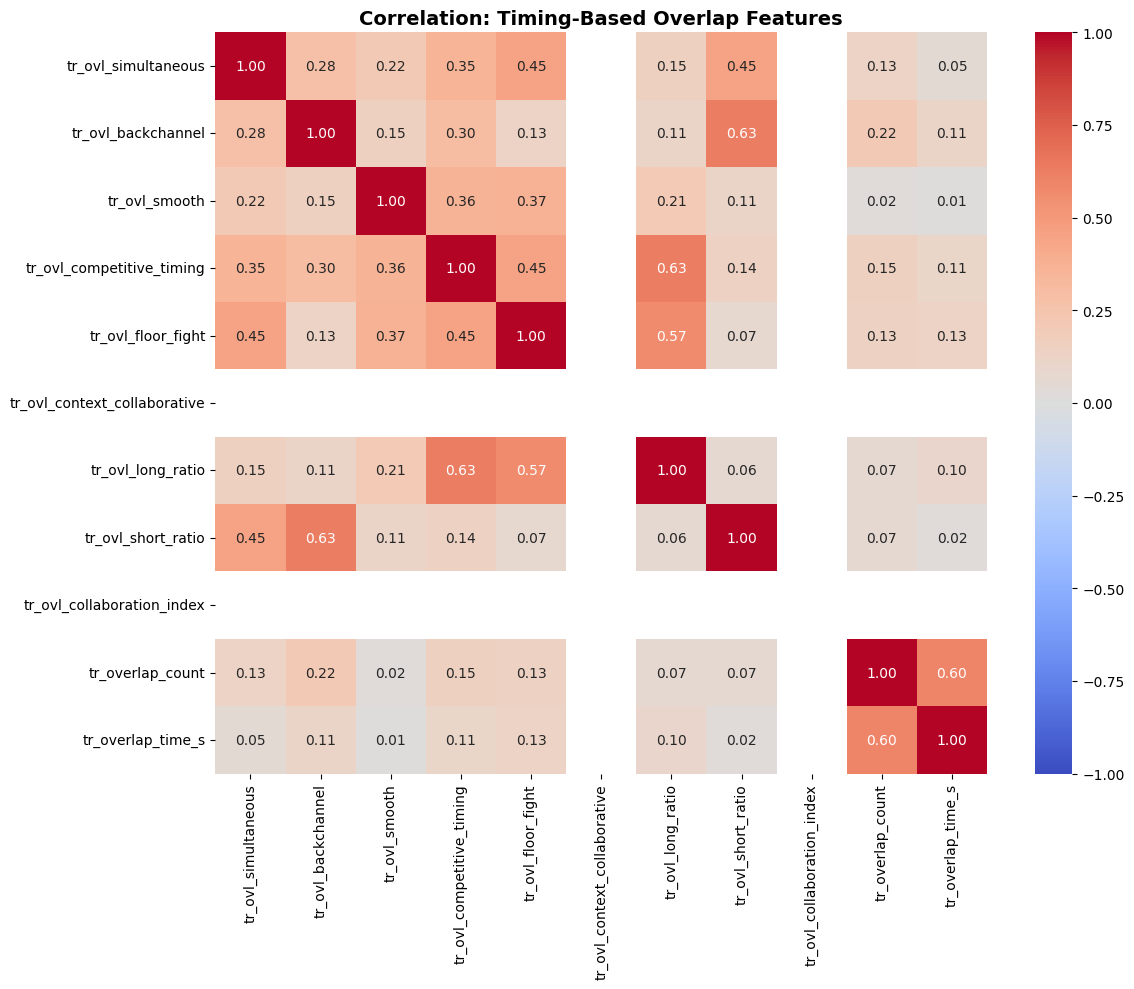

✓ Saved correlation heatmap

Correlation matrix (selected):
                              tr_ovl_simultaneous  tr_ovl_backchannel  \
tr_ovl_simultaneous                      1.000000            0.280896   
tr_ovl_backchannel                       0.280896            1.000000   
tr_ovl_smooth                            0.218007            0.153898   
tr_ovl_competitive_timing                0.352423            0.302817   
tr_ovl_floor_fight                       0.451002            0.130686   
tr_ovl_context_collaborative                  NaN                 NaN   
tr_ovl_long_ratio                        0.154273            0.114665   
tr_ovl_short_ratio                       0.451722            0.627153   
tr_ovl_collaboration_index                    NaN                 NaN   
tr_overlap_count                         0.125127            0.218504   
tr_overlap_time_s                        0.050936            0.111674   

                              tr_ovl_smooth  tr_ovl_competitive

In [13]:
# Select features for analysis
analysis_features = [
    'tr_ovl_simultaneous',
    'tr_ovl_backchannel',
    'tr_ovl_smooth',
    'tr_ovl_competitive_timing',
    'tr_ovl_floor_fight',
    'tr_ovl_context_collaborative',
    'tr_ovl_long_ratio',
    'tr_ovl_short_ratio',
    'tr_ovl_collaboration_index',
    'tr_overlap_count',  # Original
    'tr_overlap_time_s',  # Original
]

# Compute correlations
subset_for_corr = enhanced_features[[
    f for f in analysis_features if f in enhanced_features.columns
]].dropna()

corr_matrix = subset_for_corr.corr()

# Visualize
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, vmin=-1, vmax=1)
plt.title('Correlation: Timing-Based Overlap Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'overlap_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved correlation heatmap")
print(f"\nCorrelation matrix (selected):")
print(corr_matrix)

## 8. Appendix: Code snippets and configuration for reproducibility

In [16]:
appendix_code = """
# Appendix: Timing-Based Overlap Feature Construction

## Overview

This notebook documents the reconstruction of overlap features using pure timing-based subtypes
from transcript annotations, with additional collaboration-aware engineered metrics.

## Timing Subtype Definitions

The following timing-based subtypes are applied during annotation (relabel_overlaps.py):

- simultaneous: start_diff < 200 ms
- backchannel_ovl: overlap < 250 ms  
- smooth: overlap 250-500 ms
- competitive: overlap 500-1000 ms (TIMING, not semantic)
- floor_fight: overlap >= 1000 ms

All based on objective acoustic overlap duration. No annotator bias.

## Context Label Definitions

Optional context labels apply when lexical cues contradict timing classification:

- collaborative: support words (yes, and, right) detected on long overlap (competitive/floor_fight)
- competitive: conflict words (no, but, wait) detected on short overlap (backchannel/smooth/simultaneous)
- empty: when timing and lexical signals agree

## New Feature Columns

### Pure Timing Subtypes (counts per window)
- tr_ovl_simultaneous: count of simultaneous overlaps
- tr_ovl_backchannel: count of backchannel overlaps < 250ms
- tr_ovl_smooth: count of smooth overlaps 250-500ms
- tr_ovl_competitive_timing: count of timing-competitive 500-1000ms
- tr_ovl_floor_fight: count of floor_fight overlaps >= 1000ms

### Engineered Collaboration Features
- tr_ovl_long_ratio: (competitive_timing + floor_fight) / total -> long-overlap prevalence
- tr_ovl_short_ratio: (simultaneous + backchannel) / total -> short-overlap prevalence
- tr_ovl_collaboration_index: context_collaborative / total_overlaps -> lexical collaboration signal

## Feature Engineering Rationale

Previous set mixed timing counts with semantic categorization. This reconstruction separates:

1. **Timing subtypes**: Mechanics of simultaneous speech (objective, duration-based)
2. **Context labels**: Semantic/collaborative intent (subjective, lexical hints)
3. **Engineered ratios**: Normalized metrics combining both signals

Allows HMM to learn relationship between **interaction dynamics** and **emotional state**
with cleaner feature semantics and less annotator bias.

## Log Transformation

Apply log1p() preprocessing to these features (right-skewed count/duration):
- tr_silence_duration_s
- tr_backchannel_count
- tr_ovl_simultaneous, tr_ovl_smooth, tr_ovl_competitive_timing, tr_ovl_floor_fight
- tr_laughter_count
- tr_ovl_collaboration_index

## Feature Selection Decisions

1. Keep tr_backchannel_count SEPARATE from tr_ovl_backchannel 
   - BCK type = listener feedback; OVL type = acoustic overlap
   - Different dynamics, both informative

2. INCLUDE ALL 5 timing subtypes (not selective)
   - HMM learns importance via BIC
   - PCA reduces dimensionality afterward
   - Correlation not problematic

3. Keep tr_overlap_time_s AVAILABLE (not in primary CLEAN_FEATS)
   - Complements counts (duration vs. frequency)
   - Can be added if needed for specific analysis

## Updated CLEAN_FEATS (13 features)

Physiological + timing interaction features:
1. group_hr_mean_bpm_mean
2. group_eda_phasic_rate_hz_mean
3. group_temp_mean_mean
4. tr_silence_duration_s
5. tr_backchannel_count
6. tr_ovl_simultaneous
7. tr_ovl_smooth
8. tr_ovl_competitive_timing
9. tr_ovl_floor_fight
10. tr_ovl_collaboration_index
11. tr_laughter_count
12. tr_n_active_speakers
13. group_et_pupil_mean_mean
\"\"\"\n\nappendix_file = RESULTS_DIR / 'APPENDIX_TIMING_FEATURES.md'\nwith open(appendix_file, 'w', encoding='utf-8') as f:\n    f.write(appendix_code)\n\nprint(f\"✓ Saved appendix to: {appendix_file}\")\nprint(f\"\\n📄 Appendix (first 400 chars):\")\nprint(appendix_code[:400] + \"...\")

_IncompleteInputError: incomplete input (4058173847.py, line 1)